In [1]:
import os
import logging

import numpy as np
import pandas as pd
import healpy as hp

from matplotlib import pyplot as plt

from regressis.dataframe import PhotometricDataFrame
from regressis.systematics import plot_systematic_from_map
from regressis import Regression
from regressis.utils import setup_logging, read_fits_to_pandas, build_healpix_map
from regressis.footprint import DR9Footprint, DESIFootprint
from regressis.plot import plot_moll

dict_moll_param = {'figsize':(3.5, 2.0), 'xpad':1.35, 'labelpad':-16.5, 'ycb_pos':-0.10, 'xlabel_labelpad':5.0}

logger = logging.getLogger('MAIN')

# To avoid error from pandas method into the logger -> pandas use NUMEXPR Package
os.environ.setdefault('NUMEXPR_MAX_THREADS', os.environ.get('OMP_NUM_THREADS', '1'))
os.environ.setdefault('NUMEXPR_NUM_THREADS', os.environ.get('OMP_NUM_THREADS', '1'))

setup_logging()

# Plot param:
cmap = plt.get_cmap('jet', 10).copy()
cmap.set_extremes(under='darkgrey')

In [12]:
import healpy as hp
from mpytools import Catalog

# LSS = '/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/'
LSS = '/pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/' # I made a copy on my scratch for running the script
randoms_fn, data_fn = '{}_{}_{}_clustering.ran.fits', '{}_{}_clustering.dat.fits'

nside = 256
nbr_randoms = 4
tracer, zmin, zmax = 'QSO', 0.8, 3.5
regions = ['NGC', 'SGC']

data = Catalog.read([LSS + data_fn.format(tracer, reg) for reg in regions])
data['HPX'] = hp.ang2pix(nside, data['RA'], data['DEC'], nest=True, lonlat=True)
data['WEIGHT_COMP'] = data['WEIGHT_COMP'] / data['FRAC_TLOBS_TILES']

randoms = Catalog.read([LSS + randoms_fn.format(tracer, reg, i) for i in range(nbr_randoms) for reg in regions]) 

[000199.38] 26-06-18 17:05  FileStack            INFO     Reading /pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/QSO_NGC_clustering.dat.fits.
[000199.38] 26-06-18 17:05  FileStack            INFO     Reading /pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/QSO_SGC_clustering.dat.fits.
[000201.33] 26-06-18 17:05  FileStack            INFO     Reading /pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/QSO_NGC_0_clustering.ran.fits.
[000201.33] 26-06-18 17:05  FileStack            INFO     Reading /pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/QSO_SGC_0_clustering.ran.fits.
[000201.33] 26-06-18 17:05  FileStack            INFO     Reading /pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/QSO_NGC_1_clustering.ran.fits.
[000201.34] 26-06-18 17:05  FileStack            INFO     Reading /pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/QSO_SGC_1_clustering.ran.fits.
[000201.34] 26-06-18 17:05  FileStack            I

[000205.90] 26-06-18 17:05  Footprint            INFO     Load DESI footprint with nside=256
[000205.93] 26-06-18 17:05  Footprint            INFO     Load DR9 footprint with nside=256, mask_lmc=False, clear_south=False, mask_around_des=False and cut_desi=False


/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/healpy/visufunc.py:835: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


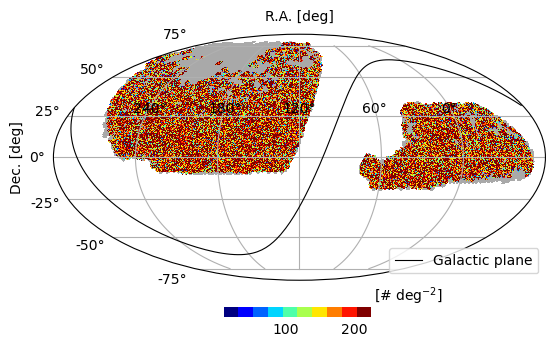

In [13]:
# Define footprint:
footprint = DESIFootprint(nside)
dr9_footprint = DR9Footprint(nside, mask_around_des=False, cut_desi=False)

# Compute healpix
map_data = build_healpix_map(nside, data['RA'], data['DEC'], in_deg2=False)
map_data_wcomp = build_healpix_map(nside, data['RA'], data['DEC'], weights=data['WEIGHT_COMP'], in_deg2=False)

map_randoms_now = build_healpix_map(nside, randoms['RA'], randoms['DEC'], in_deg2=True)

fracarea = map_randoms_now / (nbr_randoms * 2500)
fracarea[fracarea == 0] = np.nan
# remove pixels with too small fracarea
sel = 1/fracarea > 5.0
fracarea[sel] = np.nan
fracarea = fracarea

def count2moll(mp, fracarea=fracarea, footprint=footprint):
    mp_tmp = mp.copy() / hp.nside2pixarea(hp.npix2nside(mp.size), degrees=True) / fracarea
    # for visualization purposes:
    mp_tmp[footprint('y5') & np.isnan(mp_tmp)] = -1
    return mp_tmp

plot_moll(count2moll(map_data_wcomp), min=10, max=225, galactic_plane=True, cmap=cmap, label=r'[$\#$ deg$^{-2}$]', figsize=(6, 4))

In [14]:
version, tracer, suffix_tracer, nside = 'DR2', tracer, '', 256
suffix_regressor = ''
dr9_footprint = DR9Footprint(nside, mask_around_des=False, cut_desi=False)

param = {'data_dir': '/global/homes/e/edmondc/Software/regressis/data/',
         'output_dir': 'tmp/',
         'use_median': False,
         'use_new_norm': False, 
         'regions': ['North', 'South', 'Des']}

feature_names = ['STARDENS', 'EBV_DIFF_GR', 'EBV_DIFF_RZ', 'HI',
                 'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z',
                 'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFDEPTH_Z', 'PSFDEPTH_W1', 'PSFDEPTH_W2']

dataframe = PhotometricDataFrame(version, tracer, dr9_footprint, suffix_tracer, **param)
dataframe.set_features()
dataframe.set_targets(targets=map_data_wcomp, fracarea=fracarea)
dataframe.build(cut_fracarea=False)

[000273.61] 26-06-18 17:07  Footprint            INFO     Load DR9 footprint with nside=256, mask_lmc=False, clear_south=False, mask_around_des=False and cut_desi=False
[000273.64] 26-06-18 17:07  DataFrame            INFO     version: DR2 -- tracer: QSO -- regions: ['North', 'South', 'Des']
[000273.64] 26-06-18 17:07  DataFrame            INFO     Plots are saved in tmp/DR2_QSO_256/dataframe
[000273.64] 26-06-18 17:07  Utils                INFO     Read ext: 1 from /global/homes/e/edmondc/Software/regressis/data/pixweight-dr9-256.fits
[000274.13] 26-06-18 17:07  DataFrame            INFO     Read /global/homes/e/edmondc/Software/regressis/data/sagittarius_stream_256.npy
[000274.14] 26-06-18 17:07  Utils                INFO     Read ext: 1 from /global/homes/e/edmondc/Software/regressis/data/pixweight_external_256.fits
[000274.87] 26-06-18 17:07  Utils                INFO     Read ext: 1 from /global/homes/e/edmondc/Software/regressis/data/pixweight-dr9-256.fits
[000275.34] 26-06-18 17

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20260321-1.0.0/conda/lib/python3.12/site-packages/healpy/visufunc.py:835: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


[000292.80] 26-06-18 17:07  Systematics          INFO     Work with North
[000292.80] 26-06-18 17:07  Systematics          INFO     Keep only pixels with fracarea > 0


/global/u2/e/edmondc/Software/regressis/regressis/systematics.py:340: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


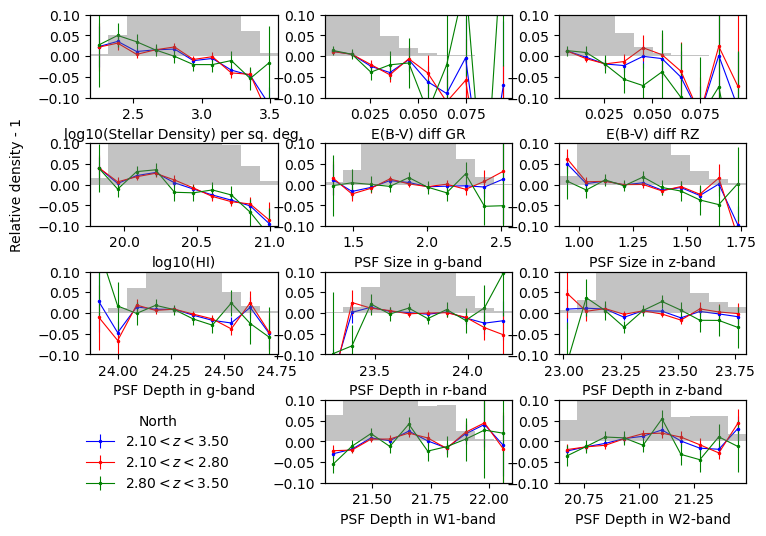

[000293.81] 26-06-18 17:07  Systematics          INFO     Work with South
[000293.82] 26-06-18 17:07  Systematics          INFO     Keep only pixels with fracarea > 0


/global/u2/e/edmondc/Software/regressis/regressis/systematics.py:340: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


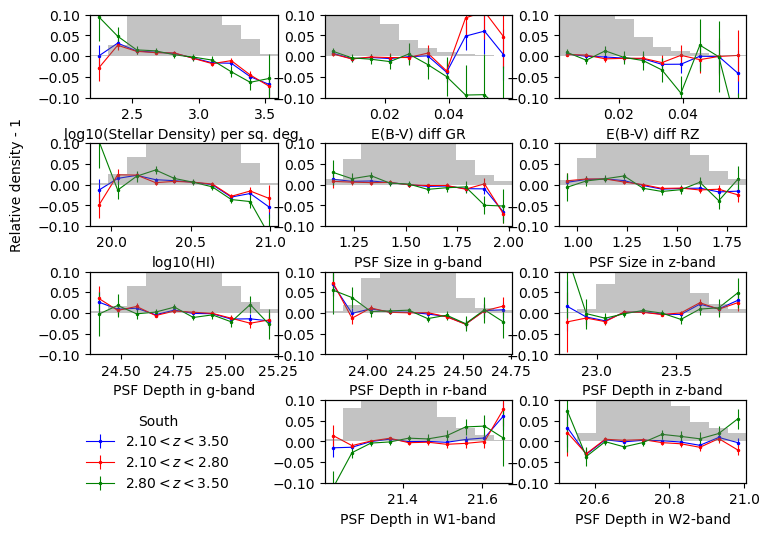

[000295.34] 26-06-18 17:07  Systematics          INFO     Work with Des
[000295.34] 26-06-18 17:07  Systematics          INFO     Keep only pixels with fracarea > 0


/global/u2/e/edmondc/Software/regressis/regressis/systematics.py:340: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


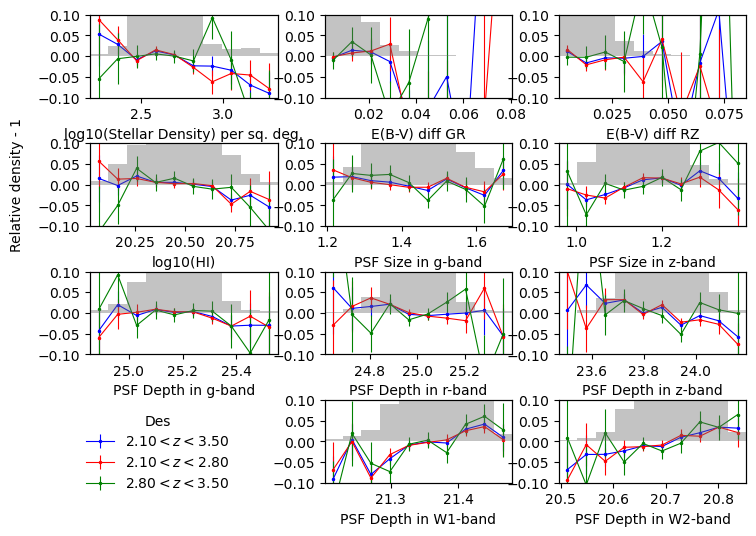

In [ ]:
zbins = [(2.1, 3.5), (2.1, 2.8), (2.8, 3.5)]
colors = ['b', 'r', 'g']

# dataframe.features_toplot[:11]
feature_names_toplot = feature_names.copy()
feature_names_toplot.remove('PSFSIZE_R')

#colors = ['k'] + list(plt.get_cmap('Blues')(np.linspace(0.3, 0.7, len(zbins) - 1)))
#colors = plt.get_cmap('jet')(np.linspace(0.2, 0.9, len(zbins)))

maps, legends = [], []
for zmin, zmax in zbins:
    sel = (zmin <= data['Z']) & (data['Z'] < zmax)
    maps.append(build_healpix_map(nside, data['RA'][sel], data['DEC'][sel], weights=data['WEIGHT_COMP'][sel] * data['WEIGHT_ZFAIL'][sel], in_deg2=True) / fracarea)
    legends.append(f"${zmin:2.2f}<z<{zmax:2.2f}$")


print('THERE IS NO CORRECTION HERE !!! ')
with np.errstate(divide='ignore', invalid='ignore'):
    plot_systematic_from_map(maps,legends,
                             fracarea, dataframe.footprint, dataframe.features, dataframe.pixels, colors=colors, 
                             feature_names = feature_names_toplot,
                             regions=['North', 'South', 'Des'],
                             ax_lim=0.1, cut_fracarea=False, legend_title=True, hist_legend=False, n_bins=10,
                             show=True, save=False, savedir='.')

In [ ]:
zbins = [(2.1, 2.4), (2.4, 2.7), (2.7, 3.0), (3.0, 3.5)]
#zbins = [(2.7, 2.85), (2.85, 3.0), (3.0, 3.15)]
colors = plt.get_cmap('jet')(np.linspace(0.2, 0.9, len(zbins)))

maps, legends = [], []
for zmin, zmax in zbins:
    sel = (zmin <= data['Z']) & (data['Z'] < zmax)
    maps.append(build_healpix_map(nside, data['RA'][sel], data['DEC'][sel], weights=data['WEIGHT_COMP'][sel] * data['WEIGHT_ZFAIL'][sel] * data['WEIGHT_SYS'][sel], in_deg2=True) / fracarea)
    legends.append(f"${zmin:2.2f}<z<{zmax:2.2f}$")

# dataframe.features_toplot[:11]
feature_names_toplot = feature_names.copy()
feature_names_toplot.remove('PSFSIZE_R')

with np.errstate(divide='ignore', invalid='ignore'):
    plot_systematic_from_map(maps,legends,
                             fracarea, dataframe.footprint, dataframe.features, dataframe.pixels, colors=colors, 
                             feature_names = feature_names_toplot,
                             regions=['South'],
                             ax_lim=0.1, cut_fracarea=False, legend_title=True, hist_legend=False, n_bins=10,
                             show=True, save=False, savedir='.')

[000328.38] 26-06-18 17:07  Systematics          INFO     Work with South
[000328.39] 26-06-18 17:07  Systematics          INFO     Keep only pixels with fracarea > 0


/global/u2/e/edmondc/Software/regressis/regressis/systematics.py:340: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


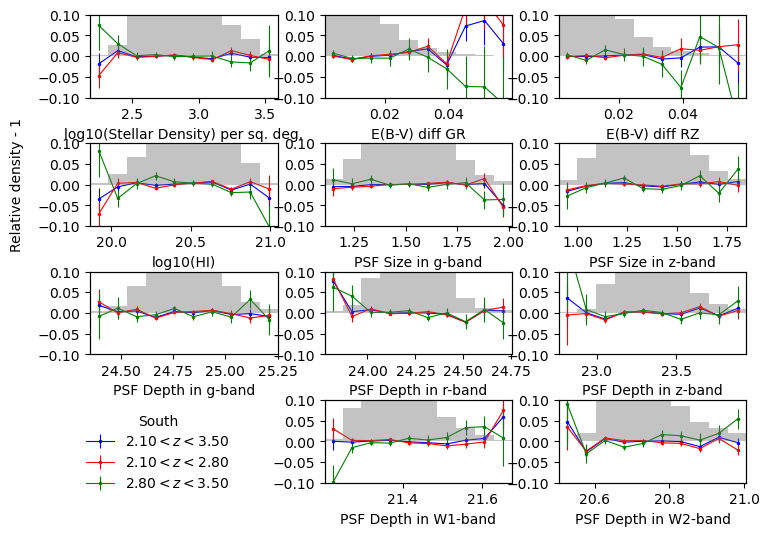

In [16]:
zbins = [(2.1, 3.5), (2.1, 2.8), (2.8, 3.5)]
colors = ['b', 'r', 'g']

maps, legends = [], []
for zmin, zmax in zbins:
    sel = (zmin <= data['Z']) & (data['Z'] < zmax)
    maps.append(build_healpix_map(nside, data['RA'][sel], data['DEC'][sel], weights=data['WEIGHT_COMP'][sel] * data['WEIGHT_ZFAIL'][sel] * data['WEIGHT_SYS'][sel], in_deg2=True) / fracarea)
    legends.append(f"${zmin:2.2f}<z<{zmax:2.2f}$")

# dataframe.features_toplot[:11]
feature_names_toplot = feature_names.copy()
feature_names_toplot.remove('PSFSIZE_R')

with np.errstate(divide='ignore', invalid='ignore'):
    plot_systematic_from_map(maps,legends,
                             fracarea, dataframe.footprint, dataframe.features, dataframe.pixels, colors=colors, 
                             feature_names = feature_names_toplot,
                             regions=['South'],
                             ax_lim=0.1, cut_fracarea=False, legend_title=True, hist_legend=False, n_bins=10,
                             show=True, save=False, savedir='.')

[000334.13] 26-06-18 17:08  Systematics          INFO     Work with South
[000334.14] 26-06-18 17:08  Systematics          INFO     Keep only pixels with fracarea > 0


/global/u2/e/edmondc/Software/regressis/regressis/systematics.py:340: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


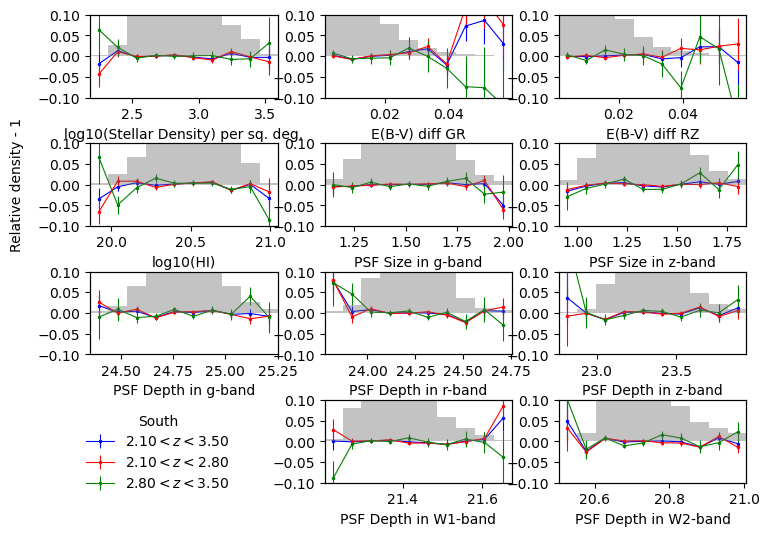

In [17]:
zbins = [(2.1, 3.5), (2.1, 2.8), (2.8, 3.5)]
colors = ['b', 'r', 'g']

maps, legends = [], []
for zmin, zmax in zbins:
    sel = (zmin <= data['Z']) & (data['Z'] < zmax)
    maps.append(build_healpix_map(nside, data['RA'][sel], data['DEC'][sel], weights=data['WEIGHT_COMP'][sel] * data['WEIGHT_ZFAIL'][sel] * data['TEST'][sel], in_deg2=True) / fracarea)
    legends.append(f"${zmin:2.2f}<z<{zmax:2.2f}$")

# dataframe.features_toplot[:11]
feature_names_toplot = feature_names.copy()
feature_names_toplot.remove('PSFSIZE_R')

with np.errstate(divide='ignore', invalid='ignore'):
    plot_systematic_from_map(maps,legends,
                             fracarea, dataframe.footprint, dataframe.features, dataframe.pixels, colors=colors, 
                             feature_names = feature_names_toplot,
                             regions=['South'],
                             ax_lim=0.1, cut_fracarea=False, legend_title=True, hist_legend=False, n_bins=10,
                             show=True, save=False, savedir='.')

[000979.53] 26-06-18 17:18  Systematics          INFO     Work with North
[000979.53] 26-06-18 17:18  Systematics          INFO     Keep only pixels with fracarea > 0


/global/u2/e/edmondc/Software/regressis/regressis/systematics.py:340: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


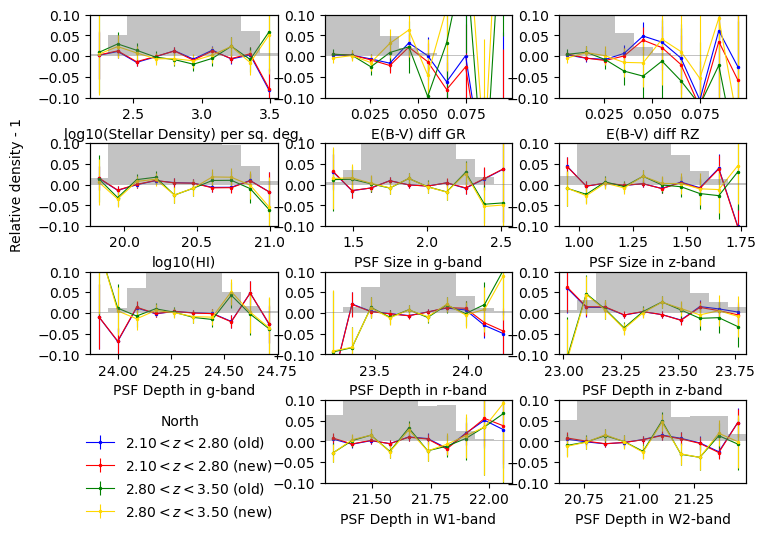

[000980.80] 26-06-18 17:18  Systematics          INFO     Work with South
[000980.81] 26-06-18 17:18  Systematics          INFO     Keep only pixels with fracarea > 0


/global/u2/e/edmondc/Software/regressis/regressis/systematics.py:340: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


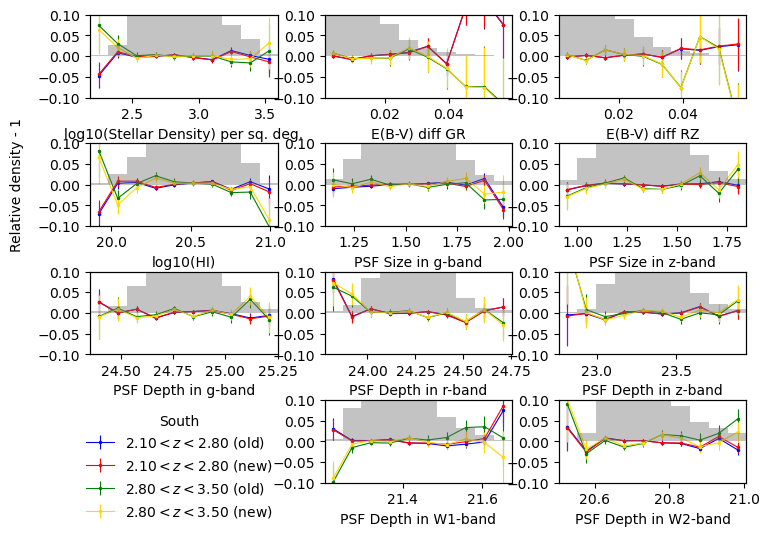

[000982.16] 26-06-18 17:18  Systematics          INFO     Work with Des
[000982.17] 26-06-18 17:18  Systematics          INFO     Keep only pixels with fracarea > 0


/global/u2/e/edmondc/Software/regressis/regressis/systematics.py:340: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


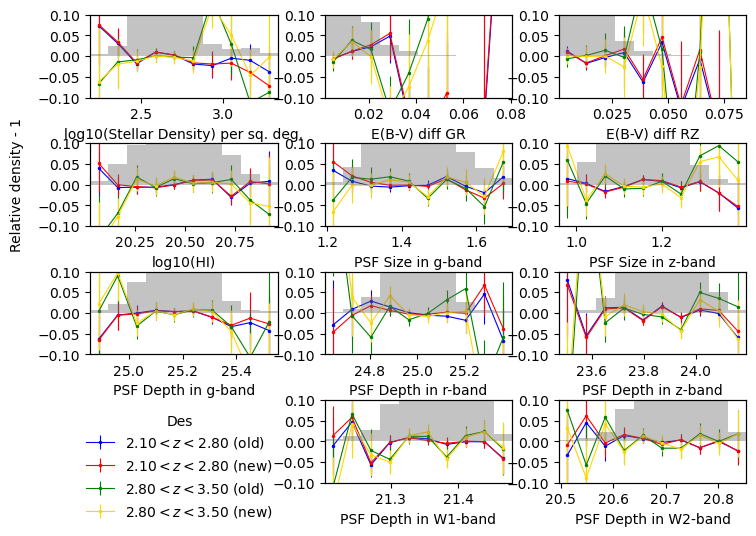

In [20]:
zbins = [(2.1, 2.8), (2.8, 3.5)]
colors = ['b', 'r', 'g', 'gold']

maps, legends = [], []
for zmin, zmax in zbins:
    sel = (zmin <= data['Z']) & (data['Z'] < zmax)
    maps.append(build_healpix_map(nside, data['RA'][sel], data['DEC'][sel], weights=data['WEIGHT_COMP'][sel] * data['WEIGHT_ZFAIL'][sel] * data['WEIGHT_SYS'][sel], in_deg2=True) / fracarea)
    legends.append(f"${zmin:2.2f}<z<{zmax:2.2f}$ (old)")
    maps.append(build_healpix_map(nside, data['RA'][sel], data['DEC'][sel], weights=data['WEIGHT_COMP'][sel] * data['WEIGHT_ZFAIL'][sel] * data['TEST'][sel], in_deg2=True) / fracarea)
    legends.append(f"${zmin:2.2f}<z<{zmax:2.2f}$ (new)")

# dataframe.features_toplot[:11]
feature_names_toplot = feature_names.copy()
feature_names_toplot.remove('PSFSIZE_R')

with np.errstate(divide='ignore', invalid='ignore'):
    plot_systematic_from_map(maps,legends,
                             fracarea, dataframe.footprint, dataframe.features, dataframe.pixels, colors=colors, 
                             feature_names = feature_names_toplot,
                             regions=['North', 'South', 'Des'],
                             ax_lim=0.1, cut_fracarea=False, legend_title=True, hist_legend=False, n_bins=10,
                             show=True, save=False, savedir='.')

In [ ]:
# To run everything from my scratch:
cp /global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/QSO* /pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/
cp /global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/blinded/QSO* /pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/blinded/
cp ~/desi_catalogs//DA2/Lcp ~/desi_catalogs//DA2/LSS/loa-v1/LSScats/v2//hpmaps/* hpmaps/

# Let's run the script:
cd /global/homes/e/edmondc/Software/LSS/scripts

perlmutter_interactive

# zrl = [(0.8,1.3), (1.3,2.1), (2.1,2.8), (2.8, 3.5)] 
python add_imlin_clus_JAX_edmond.py --type QSO --basedir /pscratch/sd/e/edmondc/catalogs/ --version v2 --imsys_zbin --new_zbin --add_syscol2blind --syscol WEIGHT_IMLIN_NEWZBIN --imsys_clus --imsys_clus_ran

# zrl = [(0.8,1.3), (1.3,2.1), (2.1,2.4), (2.4, 2.9), (2.9, 3.5)] 
python add_imlin_clus_JAX_edmond.py --type QSO --basedir /pscratch/sd/e/edmondc/catalogs/ --version v2 --imsys_zbin --new_zbin --add_syscol2blind --syscol WEIGHT_IMLIN_NEWZBIN2 --imsys_clus --imsys_clus_ran

In [22]:
Catalog.read('/pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/QSO_SGC_clustering.dat.fits')

[003244.66] 26-06-18 17:56  FileStack            INFO     Reading /pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/QSO_SGC_clustering.dat.fits.


Catalog(csize=734595, size=734595, columns=['TARGETID', 'TILEID', 'NTILE', 'RA', 'DEC', 'PHOTSYS', 'Z', 'FRAC_TLOBS_TILES', 'WEIGHT_ZFAIL', 'WEIGHT_IMLIN', 'WEIGHT_SYS', 'WEIGHT', 'WEIGHT_COMP', 'NX', 'WEIGHT_FKP', 'WEIGHT_IMLIN_ALLEBVCMB', 'TEST', 'WEIGHT_IMLIN_NEWZBIN', 'WEIGHT_IMLIN_NEWZBIN2'])

In [ ]:
a = Catalog.read('/pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/blinded/QSO_SGC_clustering.dat.fits')['WEIGHT_SYS']

aa = Catalog.read('/pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/blinded/QSO_SGC_clustering.dat.fits')['TEST']

[010451.81] 26-06-18 16:56  FileStack            INFO     Reading /pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/blinded/QSO_SGC_clustering.dat.fits.
[010451.96] 26-06-18 16:56  FileStack            INFO     Reading /pscratch/sd/e/edmondc/catalogs/DA2/LSS/loa-v1/LSScats/v2/fNL/blinded/QSO_SGC_clustering.dat.fits.
